In [1]:
import sys
import os
import numpy as np
sys.path.append(os.path.abspath(".."))
from src.preprocessing import *


In [2]:
# ============================================================
# XAI ANALYSIS - SETUP
# ============================================================

import shap
import lime
import lime.lime_tabular

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

print("SHAP version:", shap.__version__)
print("XAI environment ready")

SHAP version: 0.50.0
XAI environment ready


In [10]:
train_path = "C:/Users/Hp/Desktop/XAI-ZERODAY-IDS/data/raw/UNSW_NB15_training-set.csv"
test_path = "C:/Users/Hp/Desktop/XAI-ZERODAY-IDS/data/raw/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
drop_cols = ["id", "attack_cat"]

train_df.drop(columns=drop_cols, errors="ignore", inplace=True)
test_df.drop(columns=drop_cols, errors="ignore", inplace=True)
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Separate features and labels
X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]

X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

print("Categorical features:", list(categorical_cols))
print("Numerical features:", list(numerical_cols))

# Create transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Train shape: (175341, 45)
Test shape: (82332, 45)
Categorical features: ['proto', 'service', 'state']
Numerical features: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']
Processed train shape: (175341, 194)
Processed test shape: (82332, 194)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)
print("Feature count:", len(X_train.columns))

Scaled train shape: (175341, 194)
Scaled test shape: (82332, 194)
Training shape: (175341, 194)
Testing shape: (82332, 194)
Feature count: 42


In [17]:
# ============================================================
# XAI SETUP
# ============================================================

import shap
import lime
import lime.lime_tabular

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

print("SHAP version:", shap.__version__)
print("XAI environment ready")

SHAP version: 0.50.0
XAI environment ready


NameError: name 'train_zero_df' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

xgb_preds = xgb_model.predict(X_test_scaled)

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds))
print("Recall:", recall_score(y_test, xgb_preds))
print("F1:", f1_score(y_test, xgb_preds))

XGBoost Results:
Accuracy: 0.8515941798521109
Precision: 1.0
Recall: 0.8515941798521109
F1: 0.919849704777241


In [ ]:
X_train_normal = train_zero_df[train_zero_df["label"] == 0]
X_train_normal = X_train_normal.drop(columns=["label", "attack_cat"])

X_train_normal_scaled = scaler.fit_transform(X_train_normal)

iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.2,
    random_state=42
)

iso_model.fit(X_train_normal_scaled)

iso_scores = iso_model.decision_function(X_test_scaled)
iso_preds = np.where(iso_scores < 0, 1, 0)

print("Isolation Forest Results:")
print("Accuracy:", accuracy_score(y_test, iso_preds))
print("Precision:", precision_score(y_test, iso_preds))
print("Recall:", recall_score(y_test, iso_preds))
print("F1:", f1_score(y_test, iso_preds))
print(X_train_normal.shape)

Isolation Forest Results:
Accuracy: 0.9297527232249344
Precision: 1.0
Recall: 0.9297527232249344
F1: 0.9635977833171958
(93000, 43)


In [ ]:
hybrid_preds = np.where(
    (xgb_preds == 1) | (iso_preds == 1),
    1,
    0
)

print("Hybrid Model Results:")
print("Accuracy:", accuracy_score(y_test, hybrid_preds))
print("Precision:", precision_score(y_test, hybrid_preds))
print("Recall:", recall_score(y_test, hybrid_preds))
print("F1:", f1_score(y_test, hybrid_preds))

Hybrid Model Results:
Accuracy: 0.9833028544167925
Precision: 1.0
Recall: 0.9833028544167925
F1: 0.9915811417575369


In [ ]:
print("Normal training samples:", X_train_normal.shape)
print("Test samples:", X_test.shape)
# Fit scaler only on normal training
scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(X_train_normal)

# Transform test using SAME scaler
X_test_scaled = scaler.transform(X_test)


Normal training samples: (93000, 43)
Test samples: (75462, 43)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
from lime.lime_tabular import LimeTabularExplainer


In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [ ]:
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Feature count:", len(X_train.columns))


Train shape: (182211, 43)
Test shape: (75462, 43)
Feature count: 43


In [ ]:
# Background dataset (for baseline expectation)
background_size = 100
background = X_train_scaled[
    np.random.choice(X_train_scaled.shape[0], background_size, replace=False)
]


In [ ]:
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.2,
    random_state=42
)
iso_forest.fit(X_train_scaled)
explainer = shap.KernelExplainer(
    iso_forest.decision_function,
    background
)


In [ ]:
samples_to_explain = 50

shap_values = explainer.shap_values(
    X_test_scaled[:samples_to_explain],
    nsamples=100
)


  0%|          | 0/50 [00:00<?, ?it/s]

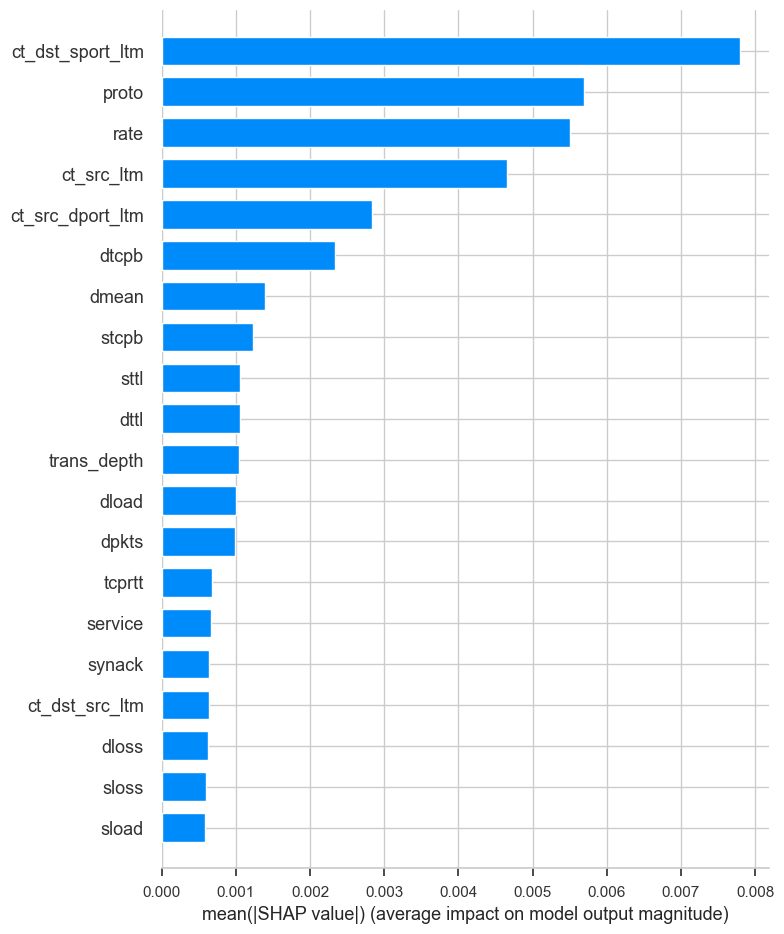

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled[:samples_to_explain],
    feature_names=X_train.columns,
    plot_type="bar"
)


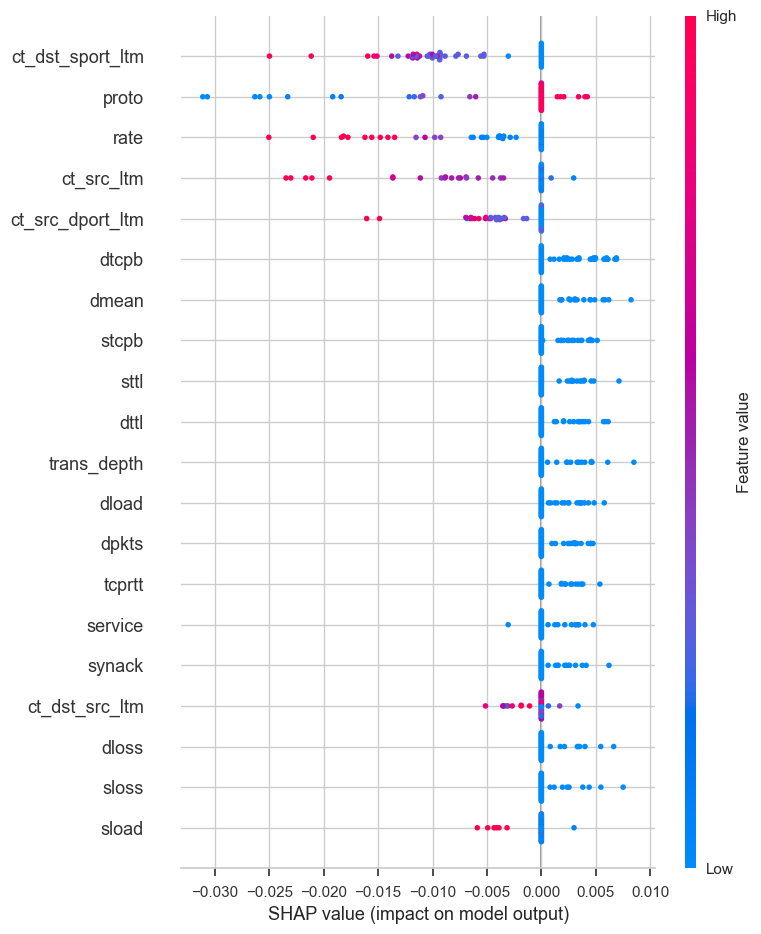

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled[:samples_to_explain],
    feature_names=X_train.columns
)


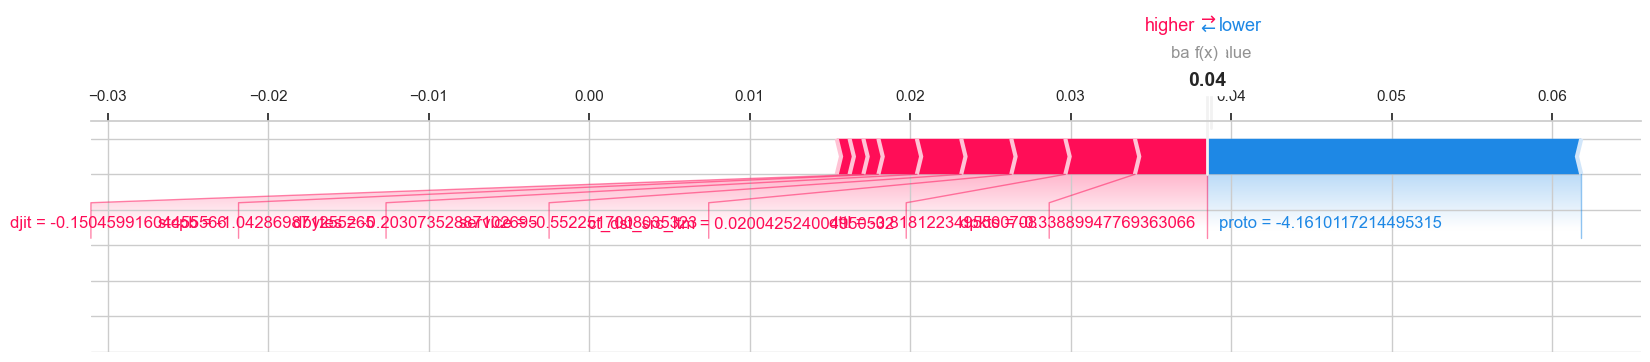

In [ ]:
index = 0  # any suspicious traffic instance

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test_scaled[index],
    feature_names=X_train.columns,
    matplotlib=True
)


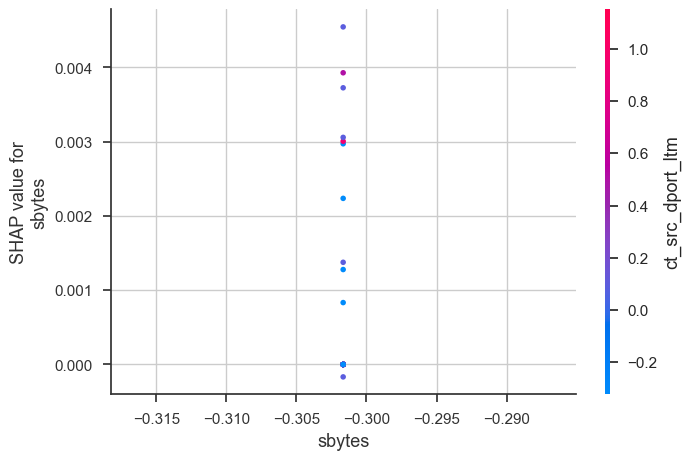

In [ ]:
shap.dependence_plot(
    "sbytes",
    shap_values,
    X_test_scaled[:samples_to_explain],
    feature_names=X_train.columns
)


In [ ]:



from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X_train.columns,
    class_names=["Normal", "Attack"],
    discretize_continuous=True,
    mode="classification"
)


In [ ]:
def iso_predict_proba(X):
    scores = iso_forest.decision_function(X)
    scores = (scores - scores.min()) / (scores.max() - scores.min())
    return np.vstack([1 - scores, scores]).T


In [ ]:
from IPython.display import HTML
i = 75 # choose any test sample

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    iso_predict_proba,
    num_features=75
)

HTML(lime_exp.as_html())


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import xgboost as xgb

plt.style.use("seaborn-v0_8")

In [ ]:
df = pd.read_csv( "C:/Users/Hp/Desktop/XAI-ZERODAY-IDS/data/raw/UNSW_NB15_training-set.csv")

df = df.drop(columns=["id", "attack_cat"], errors="ignore")

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(X_train)
X_test_xgb = scaler_xgb.transform(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_xgb, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
X_train_normal = X_train[y_train == 0]

scaler_iso = StandardScaler()
X_train_normal_scaled = scaler_iso.fit_transform(X_train_normal)
X_test_iso_scaled = scaler_iso.transform(X_test)

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42
)

iso_model.fit(X_train_normal_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [ ]:
X_train_normal = X_train[y_train == 0]

scaler_iso = StandardScaler()
X_train_normal_scaled = scaler_iso.fit_transform(X_train_normal)
X_test_iso_scaled = scaler_iso.transform(X_test)

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42
)

iso_model.fit(X_train_normal_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


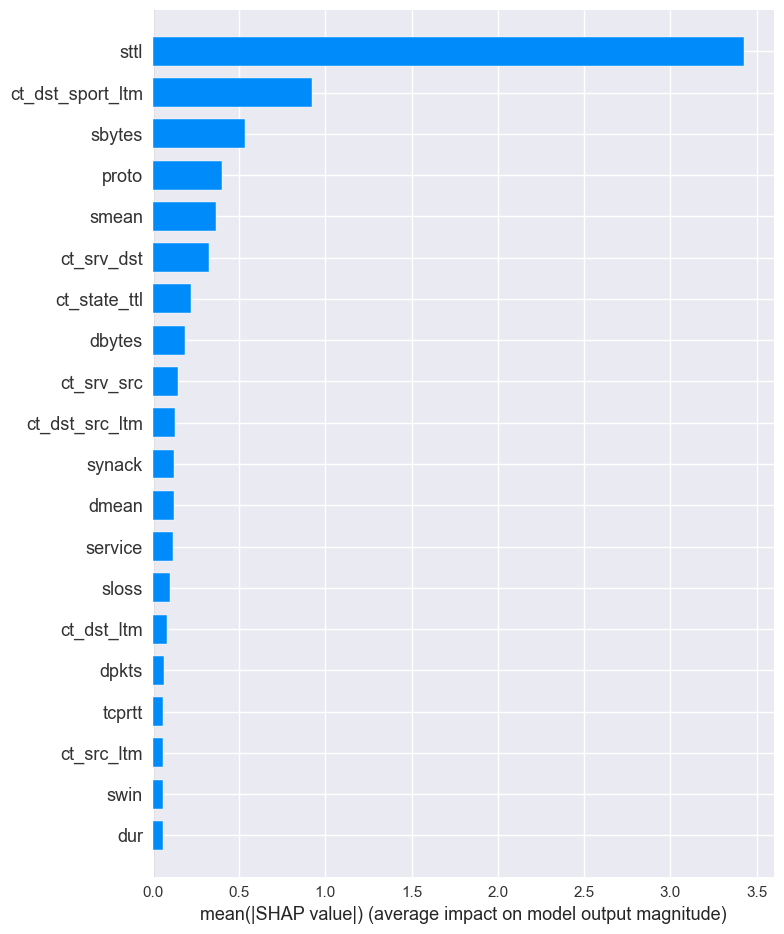

In [ ]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_xgb)

shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type="bar"
)

In [ ]:
shap.summary_plot(
    shap_values_xgb,
    X_test
)

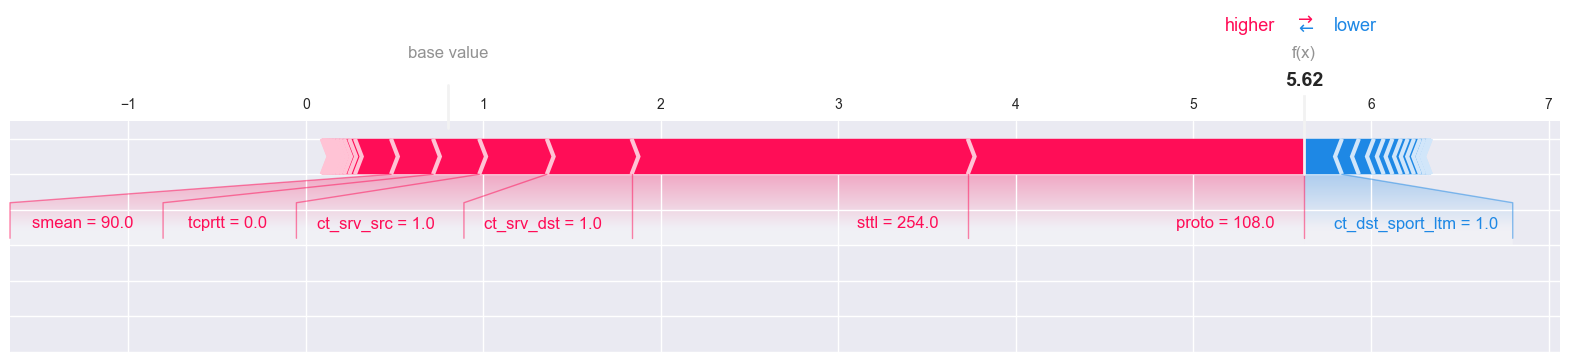

In [ ]:
sample_index = 10

shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

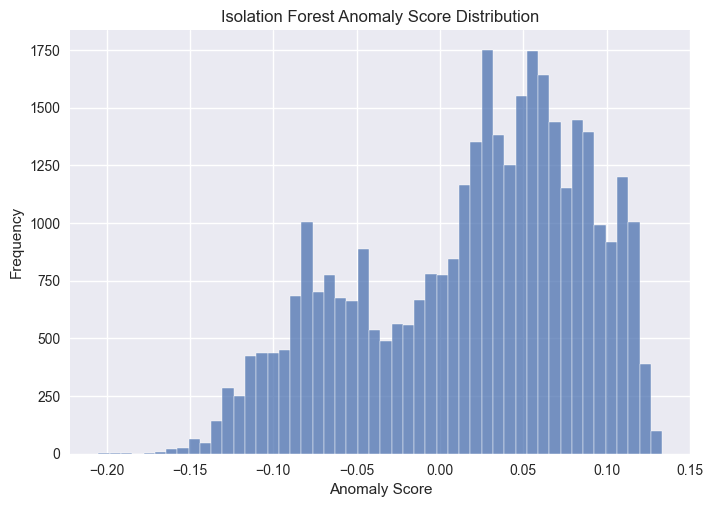

In [ ]:
anomaly_scores = iso_model.decision_function(X_test_iso_scaled)

plt.figure()
sns.histplot(anomaly_scores, bins=50)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

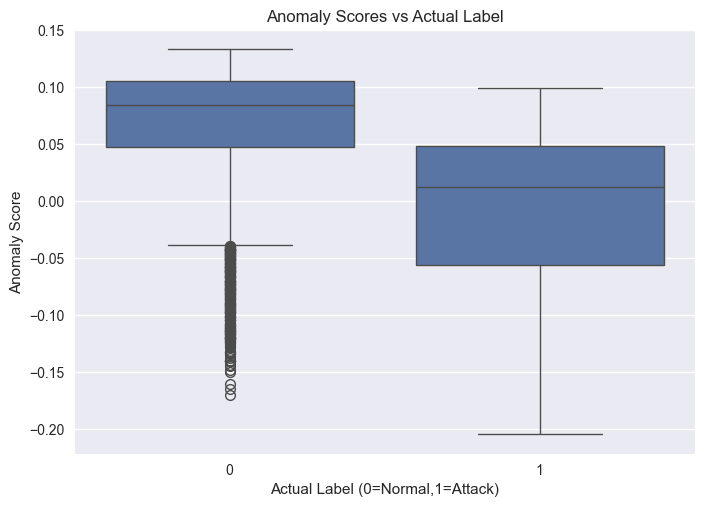

In [ ]:
plt.figure()
sns.boxplot(x=y_test, y=anomaly_scores)
plt.title("Anomaly Scores vs Actual Label")
plt.xlabel("Actual Label (0=Normal,1=Attack)")
plt.ylabel("Anomaly Score")
plt.show()

In [ ]:
def iso_predict(data):
    return iso_model.decision_function(scaler_iso.transform(data))

explainer_iso = shap.KernelExplainer(
    iso_predict,
    X_train.sample(100)
)

shap_values_iso = explainer_iso.shap_values(
    X_test.sample(50)
)

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler wa

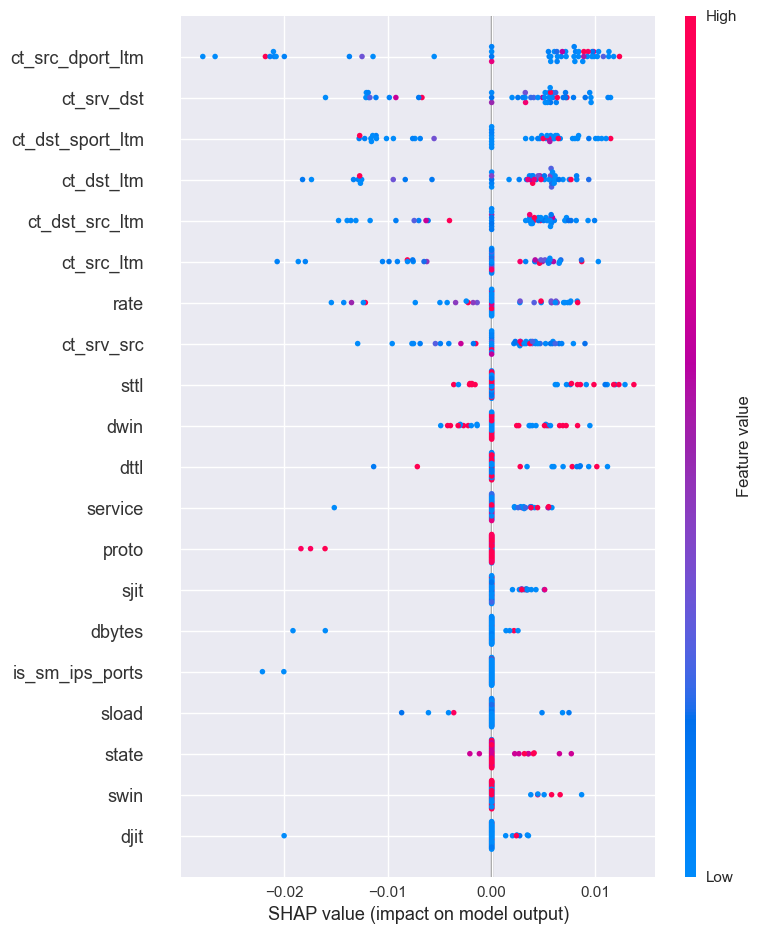

In [ ]:
shap.summary_plot(
    shap_values_iso,
    X_test.sample(50)
)

In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=["Normal", "Attack"],
    mode="classification"
)

exp = lime_explainer.explain_instance(
    X_test.iloc[5].values,
    xgb_model.predict_proba
)

from IPython.display import display, HTML

html = exp.as_html()
display(HTML(html))

In [ ]:
def iso_predict_proba(data):
    scores = iso_model.decision_function(scaler_iso.transform(data))
    probs = 1 / (1 + np.exp(-scores))
    return np.vstack([1 - probs, probs]).T

exp_iso = lime_explainer.explain_instance(
    X_test.iloc[5].values,
    iso_predict_proba
)

from IPython.display import display, HTML

html = exp.as_html()
display(HTML(html))

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


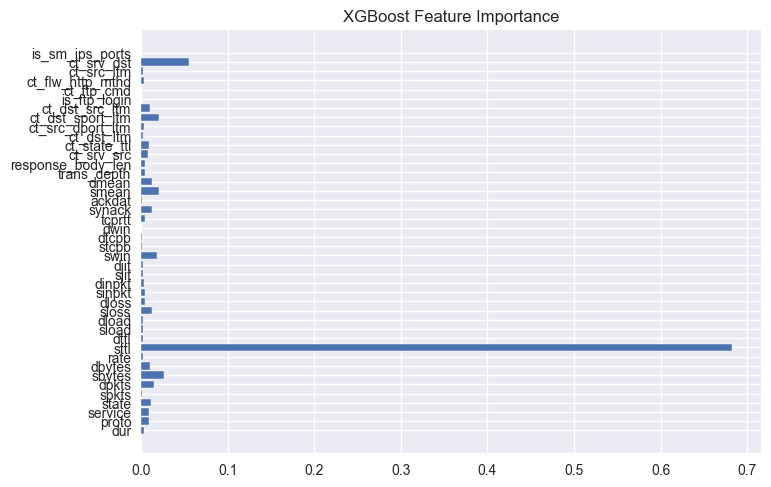

In [ ]:
xgb_importance = xgb_model.feature_importances_

plt.figure()
plt.barh(X.columns, xgb_importance)
plt.title("XGBoost Feature Importance")
plt.show()